Выполнил: Юрченко Анна Никитична М8о-310Б-23

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.base import clone
from sklearn.tree import DecisionTreeRegressor

from tqdm import tqdm
import optuna
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

Загрузка и предварительный осмотр данных

In [55]:
train = pd.read_csv("train_c.csv")
test = pd.read_csv("test_c.csv")

test_ids = test["ID"].copy()
test = test.drop(columns=["ID"])

y = train["LoanApproved"]
X = train.drop(columns=["LoanApproved"])

mask = y.notna()
X = X[mask]
y = y[mask].astype(int)

print(f"Train shape: {X.shape}, Test shape: {test.shape}")
print(f"NaN in target: {y.isna().sum()}")

Train shape: (10487, 34), Test shape: (5000, 34)
NaN in target: 0


EDA и предобработка

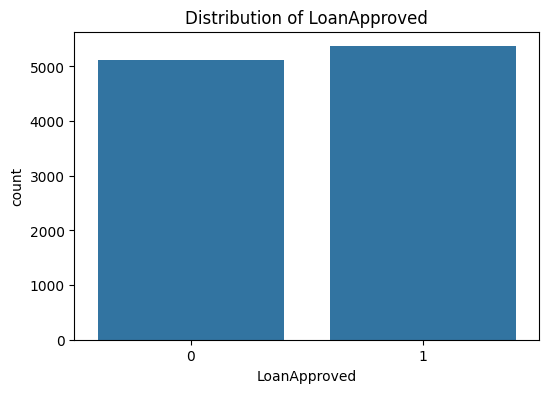

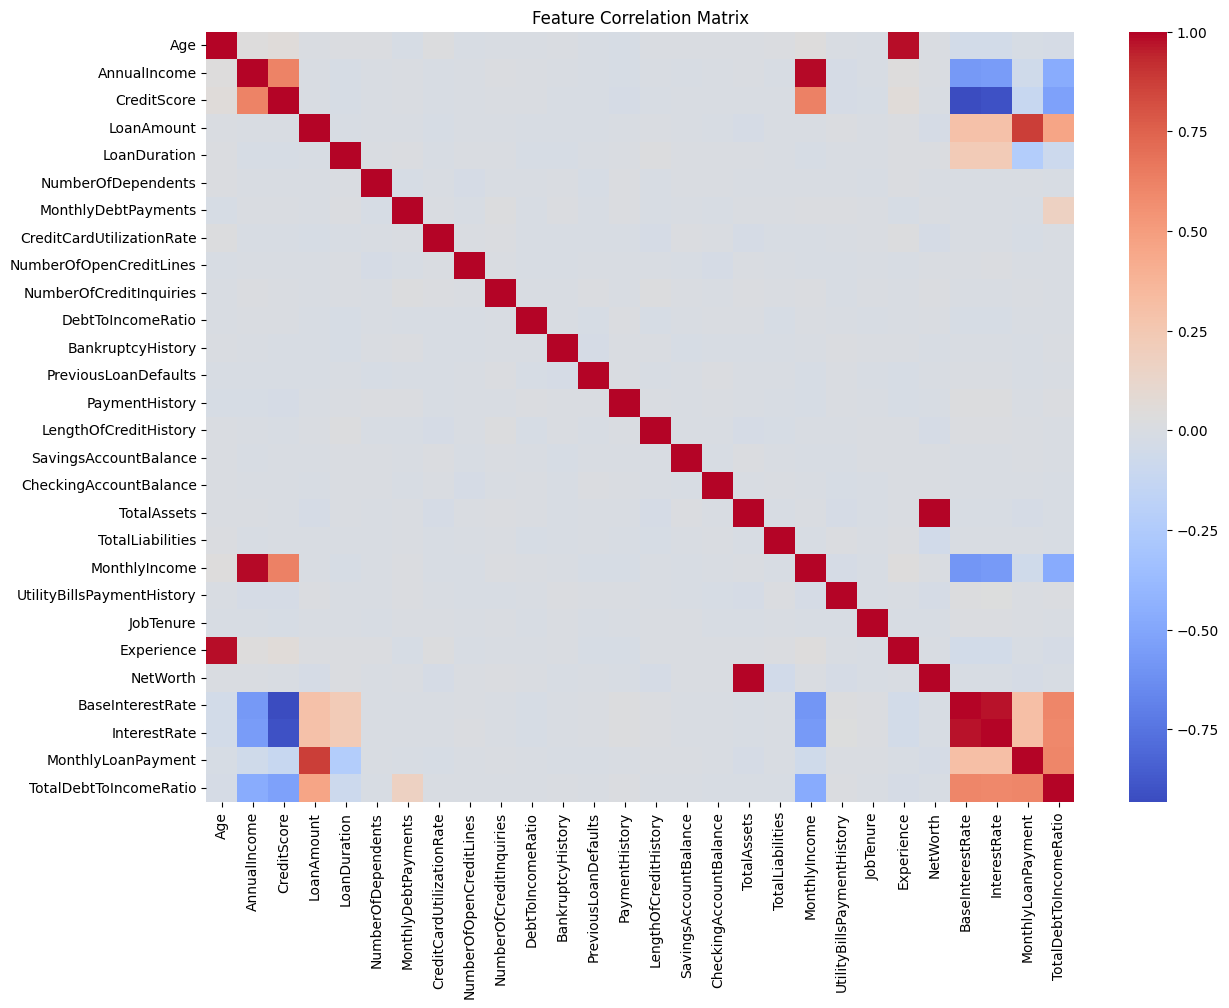

In [56]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribution of LoanApproved")
plt.show()

numeric_cols = X.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(14, 10))
sns.heatmap(X[numeric_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

X_processed = X.copy()
test_processed = test.copy()

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    all_vals = pd.concat([X[col], test[col]]).astype(str)
    le.fit(all_vals)
    X_processed[col] = le.transform(X[col].astype(str))
    test_processed[col] = le.transform(test[col].astype(str))
    label_encoders[col] = le

X_processed = X_processed.fillna(X_processed.median(numeric_only=True))
test_processed = test_processed.fillna(X_processed.median(numeric_only=True))

X_train, X_val, y_train, y_val = train_test_split(
    X_processed.values, y.values,
    test_size=0.2, random_state=42, stratify=y
)

In [57]:
class CustomBagging:
    def __init__(self, base_estimator=None, n_estimators=10, random_state=None):
        self.base_estimator = base_estimator or DecisionTreeClassifier(max_depth=3)
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.estimators_ = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.estimators_ = []
        n_samples = X.shape[0]
        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            X_boot = X[indices]
            y_boot = y[indices]
            estimator = clone(self.base_estimator)
            estimator.fit(X_boot, y_boot)
            self.estimators_.append(estimator)

    def predict_proba(self, X):
        probs = np.mean([est.predict_proba(X) for est in self.estimators_], axis=0)
        return probs

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

In [58]:
class CustomGradientBoosting:
    def __init__(self, base_estimator=None, n_estimators=10, learning_rate=0.1, random_state=None):
        self.base_estimator = base_estimator or DecisionTreeRegressor(max_depth=3)
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.estimators_ = []
        self.initial_pred_ = None

    def fit(self, X, y):
        np.random.seed(self.random_state)
        y = y.astype(float)
        p = np.clip(np.mean(y), 1e-15, 1 - 1e-15)
        self.initial_pred_ = np.log(p / (1 - p))
        F = np.full(X.shape[0], self.initial_pred_)
        self.estimators_ = []

        for _ in tqdm(range(self.n_estimators), desc="Boosting"):
            residuals = y - self._sigmoid(F)
            estimator = clone(self.base_estimator)
            estimator.fit(X, residuals)
            self.estimators_.append(estimator)
            F += self.learning_rate * estimator.predict(X)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

    def predict_proba(self, X):
        F = np.full(X.shape[0], self.initial_pred_)
        for est in self.estimators_:
            F += self.learning_rate * est.predict(X)
        proba = self._sigmoid(F)
        return np.vstack([1 - proba, proba]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)

Реализация метрик

In [59]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp + 1e-15)

def recall(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-15)

def f1_score_custom(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r + 1e-15)

def roc_auc_custom(y_true, y_score):
    return roc_auc_score(y_true, y_score)

def average_precision_custom(y_true, y_score):
    return average_precision_score(y_true, y_score)

def evaluate_model(model, X, y_true, name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    print(f"{name} → "
          f"Acc: {accuracy(y_true, y_pred):.4f}, "
          f"Prec: {precision(y_true, y_pred):.4f}, "
          f"Rec: {recall(y_true, y_pred):.4f}, "
          f"F1: {f1_score_custom(y_true, y_pred):.4f}, "
          f"AUC-ROC: {roc_auc_custom(y_true, y_proba):.4f}, "
          f"AUC-PR: {average_precision_custom(y_true, y_proba):.4f}")

Обучение кастомных и sklearn-моделей

In [60]:
custom_bag = CustomBagging(n_estimators=50, random_state=42)
custom_bag.fit(X_train, y_train)

custom_gb = CustomGradientBoosting(n_estimators=100, learning_rate=0.1, random_state=42)
custom_gb.fit(X_train, y_train)

sk_bag = BaggingClassifier(n_estimators=50, random_state=42)
sk_bag.fit(X_train, y_train)

sk_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
sk_gb.fit(X_train, y_train)

print("=== Сравнение моделей на валидации ===")
evaluate_model(custom_bag, X_val, y_val, "Custom Bagging")
evaluate_model(sk_bag, X_val, y_val, "Sklearn Bagging")
evaluate_model(custom_gb, X_val, y_val, "Custom GB")
evaluate_model(sk_gb, X_val, y_val, "Sklearn GB")

Boosting: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.72it/s]


=== Сравнение моделей на валидации ===
Custom Bagging → Acc: 0.9042, Prec: 0.8915, Rec: 0.9255, F1: 0.9082, AUC-ROC: 0.9678, AUC-PR: 0.9703
Sklearn Bagging → Acc: 0.9209, Prec: 0.9188, Rec: 0.9274, F1: 0.9231, AUC-ROC: 0.9770, AUC-PR: 0.9760
Custom GB → Acc: 0.9171, Prec: 0.9167, Rec: 0.9218, F1: 0.9192, AUC-ROC: 0.9751, AUC-PR: 0.9773
Sklearn GB → Acc: 0.9247, Prec: 0.9264, Rec: 0.9264, F1: 0.9264, AUC-ROC: 0.9808, AUC-PR: 0.9828


Сравнение готовых бустинговых моделей

In [61]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "Sklearn GB": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

best_model = None
best_score = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    print(f"{name} → ROC-AUC: {score:.4f}")
    if score > best_score:
        best_score = score
        best_model = model

print(f"\nЛучшая модель: {type(best_model).__name__} с ROC-AUC = {best_score:.4f}")

Sklearn GB → ROC-AUC: 0.9808
XGBoost → ROC-AUC: 0.9812
[LightGBM] [Info] Number of positive: 4293, number of negative: 4096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001460 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4841
[LightGBM] [Info] Number of data points in the train set: 8389, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.511742 -> initscore=0.046975
[LightGBM] [Info] Start training from score 0.046975
LightGBM → ROC-AUC: 0.9812
CatBoost → ROC-AUC: 0.9828

Лучшая модель: CatBoostClassifier с ROC-AUC = 0.9828


Подбор гиперпараметров через Optuna

In [67]:
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "verbose": False,
        "random_state": 42
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best params:", study.best_params)

final_model = CatBoostClassifier(**study.best_params, verbose=False, random_state=42)
final_model.fit(X_train, y_train)

[I 2025-12-12 01:58:17,535] A new study created in memory with name: no-name-8b734890-10fe-4600-8d67-c743a7dc1602
[I 2025-12-12 01:58:19,891] Trial 0 finished with value: 0.9827974060172253 and parameters: {'iterations': 616, 'depth': 6, 'learning_rate': 0.22334645053746377, 'random_strength': 1.8197427897656209, 'l2_leaf_reg': 7.503465414545562, 'bagging_temperature': 0.6348199489955421, 'border_count': 61}. Best is trial 0 with value: 0.9827974060172253.
[I 2025-12-12 01:58:22,213] Trial 1 finished with value: 0.982268207344041 and parameters: {'iterations': 524, 'depth': 5, 'learning_rate': 0.25355263199945316, 'random_strength': 1.9926023039228453, 'l2_leaf_reg': 8.816753278258659, 'bagging_temperature': 0.2690504680956036, 'border_count': 249}. Best is trial 0 with value: 0.9827974060172253.
[I 2025-12-12 01:58:28,095] Trial 2 finished with value: 0.9823063969390131 and parameters: {'iterations': 545, 'depth': 8, 'learning_rate': 0.22212690137099522, 'random_strength': 0.505993196

Best params: {'iterations': 866, 'depth': 7, 'learning_rate': 0.09745166932396412, 'random_strength': 1.0088219506230998, 'l2_leaf_reg': 2.1036732859804026, 'bagging_temperature': 0.2905819411035724, 'border_count': 183}


Генерация submission и финальная проверка

In [68]:
test_pred = final_model.predict_proba(test_processed.values)[:, 1]

submission = pd.DataFrame({
    "ID": test_ids,
    "LoanApproved": test_pred
})
submission.to_csv("submission.csv", index=False)
print("Файл submission.csv сохранён.")

y_val_pred = final_model.predict_proba(X_val)[:, 1]
print("\n=== Финальная модель на валидации ===")
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_pred):.4f}")
print(f"AUC-PR: {average_precision_score(y_val, y_val_pred):.4f}")
print(f"Accuracy: {accuracy(y_val, (y_val_pred > 0.5).astype(int)):.4f}")

Файл submission.csv сохранён.

=== Финальная модель на валидации ===
ROC-AUC: 0.9834
AUC-PR: 0.9850
Accuracy: 0.9280


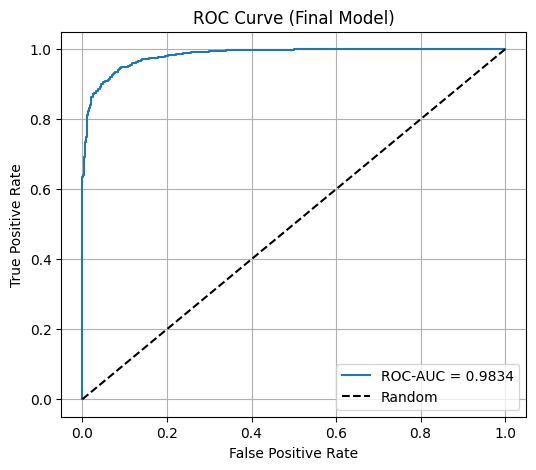

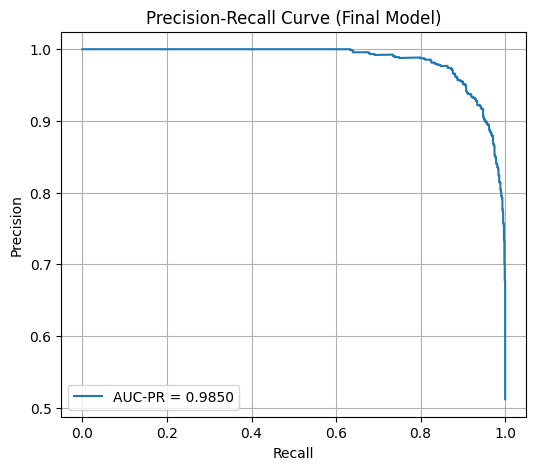

In [69]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_val, y_val_pred)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_val, y_val_pred):.4f}")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Final Model)")
plt.legend()
plt.grid()
plt.show()

precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred)
plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, label=f"AUC-PR = {average_precision_score(y_val, y_val_pred):.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Final Model)")
plt.legend()
plt.grid()
plt.show()

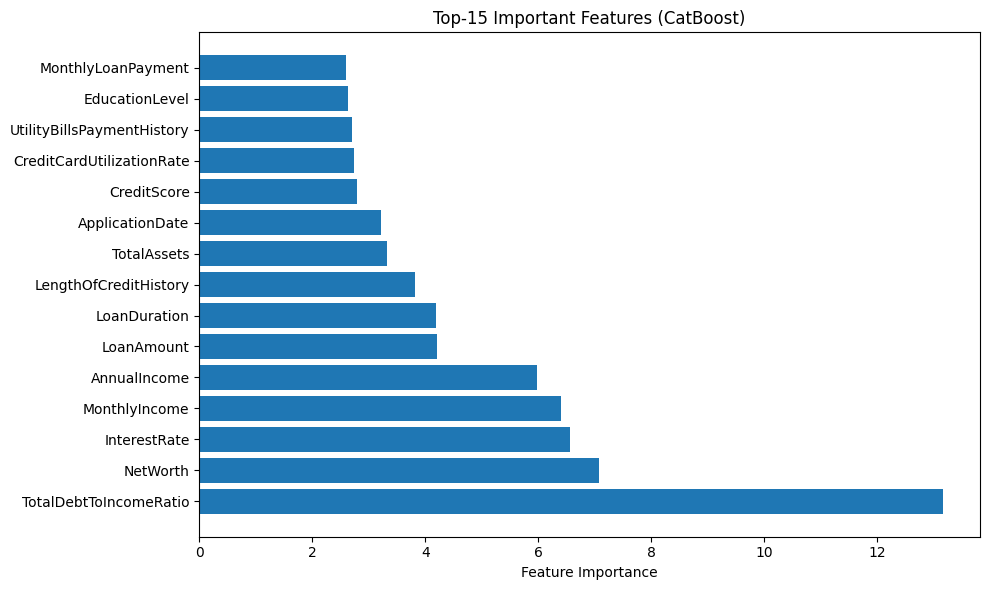

In [70]:
importance = final_model.get_feature_importance()
features = X_processed.columns
plt.figure(figsize=(10, 6))
indices = np.argsort(importance)[::-1][:15]  # Top-15
plt.barh(range(15), importance[indices][::-1])
plt.yticks(range(15), [features[i] for i in indices][::-1])
plt.xlabel("Feature Importance")
plt.title("Top-15 Important Features (CatBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()